# Healthcare Operations Analytics & 30-Day Readmission Prediction

## Project Overview

This project analyzes hospital patient records to identify factors associated with 30-day readmissions.

### Objectives
- Calculate overall readmission rate
- Identify high-risk patient groups
- Analyze the impact of age, comorbidities, and insurance type
- Support future Power BI dashboard development
- Build a foundation for readmission prediction models

### Dataset
- 100,000 Patients
- 11,001 Hospital Admissions
- 2018–2024
- Synthetic EHR Dataset

## 1. Data Loading

In this section, patient and outcome datasets are loaded into Python for analysis.

In [2]:
import pandas as pd

patients = pd.read_csv("../data/raw/patients.csv")
outcomes = pd.read_csv("../data/raw/outcomes.csv")

print("Patients Shape:", patients.shape)
print("Outcomes Shape:", outcomes.shape)

Patients Shape: (100000, 28)
Outcomes Shape: (11001, 12)


## 2. Initial Data Exploration

Review the structure and sample records of each dataset.

In [3]:
patients.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0000001,66,M,23.5,148,81,64,98.4,former,light,...,0,0,1,0,0,0,0,0,1,0
1,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,0,0,0,0,1,0,0,0,1,0
2,P0000003,82,M,17.8,135,57,90,98.2,never,light,...,0,0,1,0,0,0,0,0,0,0
3,P0000004,73,F,28.1,118,83,102,98.9,former,moderate,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,86,F,30.6,156,81,56,98.7,never,heavy,...,0,0,0,0,1,1,0,1,0,0


In [4]:
outcomes.head()

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,days_to_readmission,primary_drg,total_charges_usd
0,P0000002,2024-08-06,2024-08-09,3,0,0,0,home_health,0,NaN,291,8589.79
1,P0000003,2022-05-06,2022-05-08,2,0,0,0,hospice,1,28.0,392,22628.17
2,P0000011,2021-12-30,2022-01-08,9,0,0,0,rehab,0,NaN,392,27565.97
3,P0000014,2022-06-30,2022-07-04,4,0,0,0,home,0,NaN,194,10332.33
4,P0000040,2020-09-19,2020-09-20,1,0,0,0,rehab,0,NaN,470,2389.61


## 3. Data Quality Assessment

Check data types, column structures, and missing values.

In [5]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   patient_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   sex                         100000 non-null  object 
 3   bmi                         100000 non-null  float64
 4   systolic_bp                 100000 non-null  int64  
 5   diastolic_bp                100000 non-null  int64  
 6   heart_rate                  100000 non-null  int64  
 7   temperature_f               100000 non-null  float64
 8   smoking_status              100000 non-null  object 
 9   alcohol_use                 100000 non-null  object 
 10  exercise_level              100000 non-null  object 
 11  insurance_type              100000 non-null  object 
 12  charlson_index              100000 non-null  int64  
 13  dx_hypertension

In [6]:
outcomes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11001 entries, 0 to 11000
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             11001 non-null  object 
 1   admission_date         11001 non-null  object 
 2   discharge_date         11001 non-null  object 
 3   length_of_stay_days    11001 non-null  int64  
 4   icu_admission          11001 non-null  int64  
 5   icu_days               11001 non-null  int64  
 6   in_hospital_death      11001 non-null  int64  
 7   discharge_disposition  11001 non-null  object 
 8   readmitted_30d         11001 non-null  int64  
 9   days_to_readmission    1643 non-null   float64
 10  primary_drg            11001 non-null  int64  
 11  total_charges_usd      11001 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 1.0+ MB


### Missing Value Analysis

Missing values can significantly impact healthcare analytics and predictive modeling. This step verifies data completeness.

In [7]:
patients.isnull().sum()

patient_id                    0
age                           0
sex                           0
bmi                           0
systolic_bp                   0
diastolic_bp                  0
heart_rate                    0
temperature_f                 0
smoking_status                0
alcohol_use                   0
exercise_level                0
insurance_type                0
charlson_index                0
dx_hypertension               0
dx_type2_diabetes             0
dx_hyperlipidemia             0
dx_obesity                    0
dx_coronary_artery_disease    0
dx_heart_failure              0
dx_atrial_fibrillation        0
dx_chronic_kidney_disease     0
dx_copd                       0
dx_asthma                     0
dx_depression                 0
dx_anxiety                    0
dx_hypothyroidism             0
dx_osteoarthritis             0
dx_type1_diabetes             0
dtype: int64

In [8]:
outcomes.isnull().sum()

patient_id                  0
admission_date              0
discharge_date              0
length_of_stay_days         0
icu_admission               0
icu_days                    0
in_hospital_death           0
discharge_disposition       0
readmitted_30d              0
days_to_readmission      9358
primary_drg                 0
total_charges_usd           0
dtype: int64

## 4. Data Integration

Merge patient demographics with hospital outcome records using patient_id.

This creates a single analytical dataset for readmission analysis.

In [9]:
df = patients.merge(
    outcomes,
    on="patient_id",
    how="inner"
)

print(df.shape)

(11001, 39)


## 5. Readmission Rate Analysis

The primary KPI for this project is the 30-day hospital readmission rate.

In [10]:
df["readmitted_30d"].value_counts()

readmitted_30d
0    9358
1    1643
Name: count, dtype: int64

In [11]:
df["readmitted_30d"].value_counts(normalize=True)

readmitted_30d
0    0.85065
1    0.14935
Name: proportion, dtype: float64

In [12]:
readmission_rate = df["readmitted_30d"].mean()

print(f"Readmission Rate: {readmission_rate:.2%}")

Readmission Rate: 14.94%


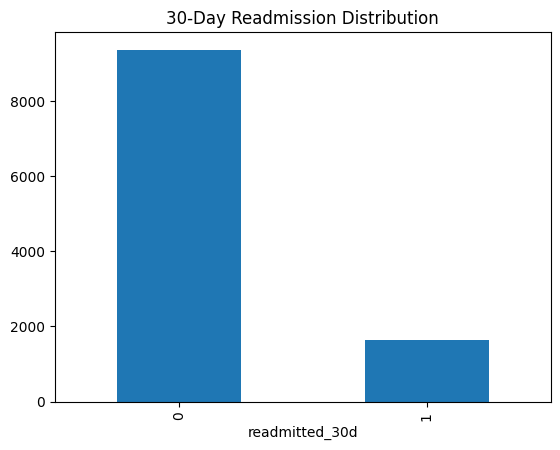

In [13]:
import matplotlib.pyplot as plt

df["readmitted_30d"].value_counts().plot(
    kind="bar"
)

plt.title("30-Day Readmission Distribution")
plt.show()

## 6. Age Group Analysis

Objective:
Determine whether patient age is associated with increased readmission risk.

Approach:
Patients are grouped into four age categories:
- 18–34
- 35–49
- 50–64
- 65+

In [14]:
df.groupby("age")["readmitted_30d"].mean()

age
20    0.000000
22    0.000000
23    0.000000
24    0.000000
25    0.000000
        ...   
91    0.227799
92    0.157088
93    0.134884
94    0.150235
95    0.148575
Name: readmitted_30d, Length: 75, dtype: float64

In [15]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 35, 50, 65, 100],
    labels=["18-34", "35-49", "50-64", "65+"],
    right=False
)

In [16]:
age_analysis = (
    df.groupby("age_group")["readmitted_30d"]
      .mean()
      .sort_values(ascending=False)
)

print(age_analysis)

age_group
65+      0.159448
50-64    0.110870
35-49    0.103041
18-34    0.068376
Name: readmitted_30d, dtype: float64


/var/folders/5x/5rrpz_sx02s1x287kb1wkgzh0000gn/T/ipykernel_25302/987952498.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["readmitted_30d"]


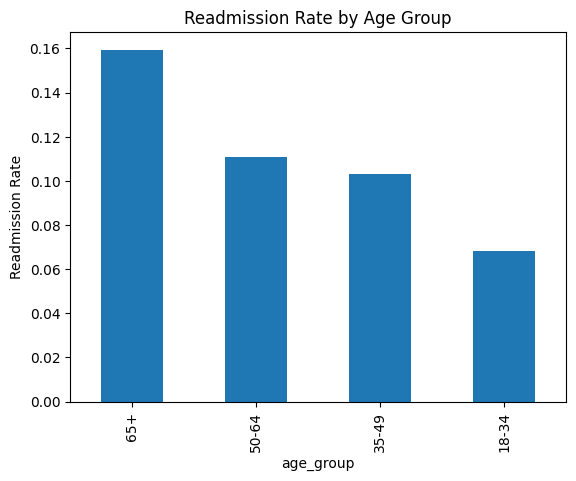

In [17]:
age_analysis.plot(kind="bar")

plt.title("Readmission Rate by Age Group")
plt.ylabel("Readmission Rate")
plt.show()

### Key Finding

Patients aged 65+ demonstrated the highest readmission rate (15.9%).

The readmission rate for patients aged 65+ was more than twice that of patients aged 18–34, suggesting age is an important risk factor.

## 7. Charlson Comorbidity Index Analysis

Objective:
Evaluate whether patients with more severe comorbidities experience higher readmission rates.

The Charlson Index is a commonly used healthcare risk score that summarizes patient disease burden.

In [18]:
df["charlson_index"].value_counts().sort_index()

charlson_index
0    3483
1    2577
2    3080
3    1498
4     329
5      33
6       1
Name: count, dtype: int64

In [19]:
df.groupby("charlson_index")["readmitted_30d"].mean()

charlson_index
0    0.094746
1    0.136593
2    0.183766
3    0.208945
4    0.209726
5    0.393939
6    0.000000
Name: readmitted_30d, dtype: float64

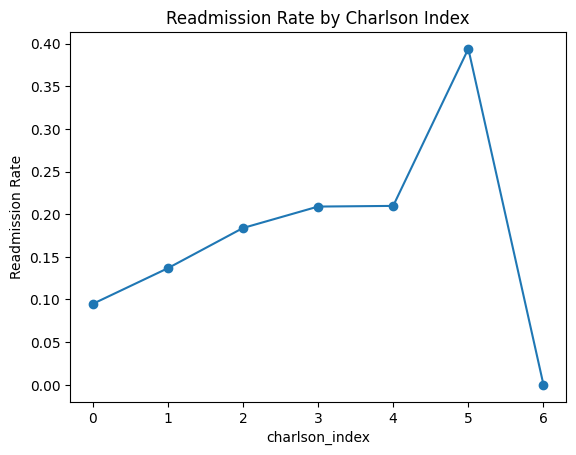

In [20]:
df.groupby("charlson_index")["readmitted_30d"].mean().plot(
    kind="line",
    marker="o"
)

plt.title("Readmission Rate by Charlson Index")
plt.ylabel("Readmission Rate")
plt.show()

### Key Finding

Readmission rates increased consistently as Charlson Index scores increased.

Patients with a Charlson Index of 5 experienced a readmission rate of 39.4%, compared to only 9.4% for patients with a score of 0.

This indicates that comorbidity burden is strongly associated with hospital readmissions.

## 8. Insurance Type Analysis

Objective:
Investigate whether readmission rates differ across insurance categories.

In [21]:
insurance_analysis = (
    df.groupby("insurance_type")["readmitted_30d"]
      .mean()
      .sort_values(ascending=False)
)

print(insurance_analysis)

insurance_type
tricare       0.159498
commercial    0.150849
uninsured     0.149542
medicaid      0.147374
medicare      0.144366
Name: readmitted_30d, dtype: float64


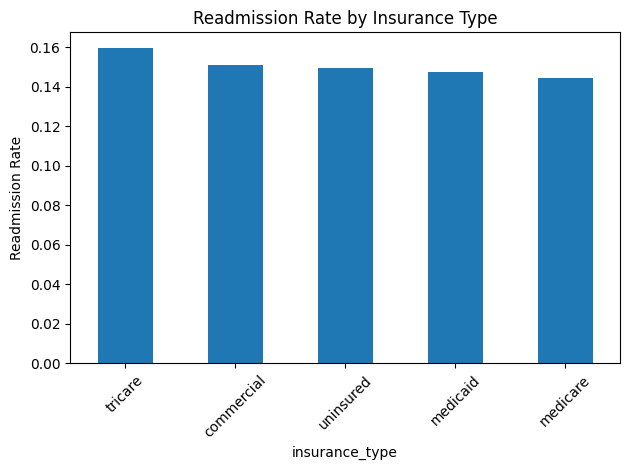

In [22]:
insurance_analysis.plot(
    kind="bar",
    rot=45
)

plt.title("Readmission Rate by Insurance Type")
plt.ylabel("Readmission Rate")
plt.tight_layout()
plt.show()

## 9. ICU Admission Analysis

### Objective

Determine whether ICU admission is associated with increased 30-day readmission risk.

### Business Question

Are patients admitted to the ICU more likely to be readmitted than patients who were not admitted to the ICU?

In [23]:
icu_analysis = (
    df.groupby("icu_admission")["readmitted_30d"]
      .mean()
)

print(icu_analysis)

icu_admission
0    0.148010
1    0.208163
Name: readmitted_30d, dtype: float64


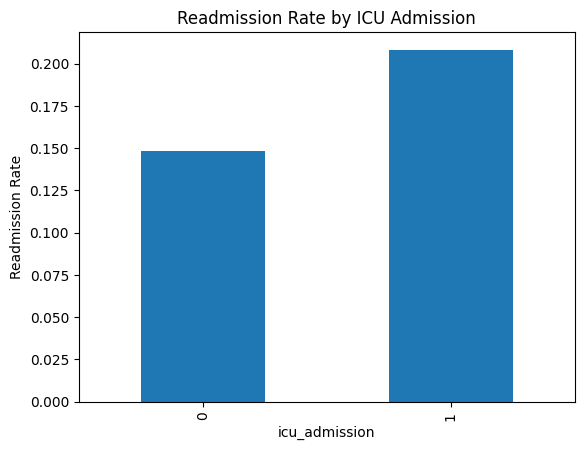

In [24]:
icu_analysis.plot(kind="bar")

plt.title("Readmission Rate by ICU Admission")
plt.ylabel("Readmission Rate")
plt.show()

### Key Finding

Patients admitted to the ICU experienced a readmission rate of approximately 20.8%, compared to 14.9% among non-ICU patients.

This finding suggests that ICU admission may serve as an indicator of disease severity and future readmission risk.

## 10. Length of Stay Analysis

### Objective

Evaluate whether longer hospital stays are associated with higher readmission rates.

### Business Question

Does the duration of hospitalization influence the likelihood of readmission?

In [25]:
df["los_group"] = pd.cut(
    df["length_of_stay_days"],
    bins=[0,3,7,14,31],
    labels=["1-3 Days","4-7 Days","8-14 Days","15+ Days"]
)

In [26]:
los_analysis = (
    df.groupby("los_group")["readmitted_30d"]
      .mean()
)

print(los_analysis)

los_group
1-3 Days     0.145829
4-7 Days     0.147624
8-14 Days    0.162971
15+ Days     0.147303
Name: readmitted_30d, dtype: float64


/var/folders/5x/5rrpz_sx02s1x287kb1wkgzh0000gn/T/ipykernel_25302/3784099091.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("los_group")["readmitted_30d"]


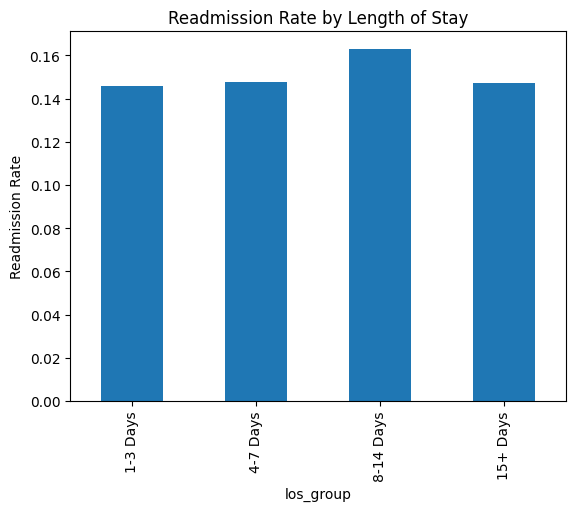

In [27]:
los_analysis.plot(kind="bar")

plt.title("Readmission Rate by Length of Stay")
plt.ylabel("Readmission Rate")
plt.show()

### Key Finding

Readmission rates remained relatively stable across most length-of-stay groups.

Patients hospitalized for 8–14 days showed a slightly higher readmission rate; however, the overall relationship between length of stay and readmission was weaker than observed for age, comorbidity burden, and ICU admission.

## 11. Disease-Specific Readmission Analysis

### Objective

Identify which chronic conditions are most strongly associated with 30-day hospital readmissions.

### Conditions Evaluated

- Heart Failure
- Chronic Kidney Disease (CKD)
- Type 2 Diabetes
- COPD

In [28]:
df.groupby("dx_heart_failure")["readmitted_30d"].mean()

dx_heart_failure
0    0.148328
1    0.171908
Name: readmitted_30d, dtype: float64

In [29]:
df.groupby("dx_chronic_kidney_disease")["readmitted_30d"].mean()

dx_chronic_kidney_disease
0    0.120748
1    0.195487
Name: readmitted_30d, dtype: float64

In [30]:
df.groupby("dx_type2_diabetes")["readmitted_30d"].mean()

dx_type2_diabetes
0    0.143276
1    0.170385
Name: readmitted_30d, dtype: float64

In [31]:
df.groupby("dx_copd")["readmitted_30d"].mean()

dx_copd
0    0.144447
1    0.183394
Name: readmitted_30d, dtype: float64

### Disease Comparison Findings

Among the evaluated chronic conditions, chronic kidney disease (CKD) showed the strongest association with readmission risk, followed by COPD.

Heart failure and Type 2 diabetes were associated with moderate increases in readmission rates.

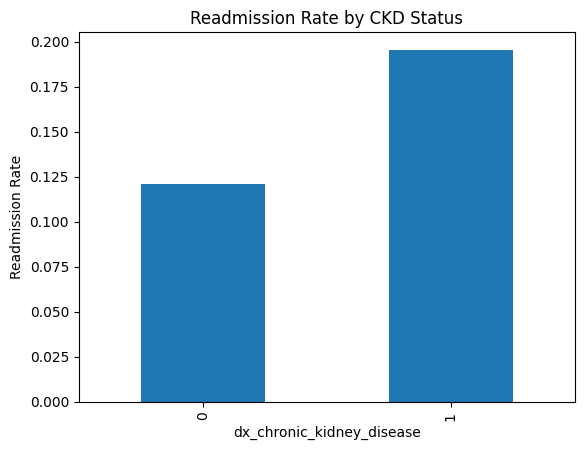

In [32]:
ckd_analysis = (
    df.groupby("dx_chronic_kidney_disease")["readmitted_30d"]
      .mean()
)

ckd_analysis.plot(kind="bar")

plt.title("Readmission Rate by CKD Status")
plt.ylabel("Readmission Rate")
plt.show()

<Axes: >

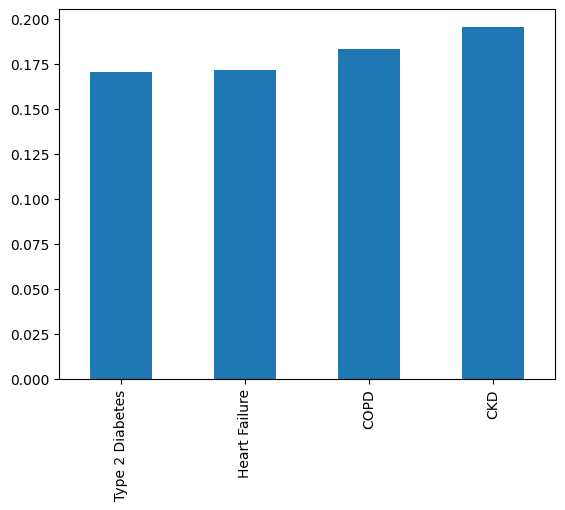

In [33]:
disease_rates = {
    "Heart Failure": 0.1719,
    "CKD": 0.1955,
    "Type 2 Diabetes": 0.1704,
    "COPD": 0.1834
}

pd.Series(disease_rates).sort_values().plot(kind="bar")

### Key Finding

Patients with chronic kidney disease (CKD) demonstrated a readmission rate of 19.5%, compared to 12.1% among patients without CKD.

This represents one of the strongest disease-specific predictors of readmission identified in the analysis.

# Final Summary

## Key Findings

1. Patients aged 65+ had the highest readmission rate (15.9%).

2. Charlson Comorbidity Index was strongly associated with readmission risk, increasing from 9.4% to 39.4%.

3. ICU patients experienced higher readmission rates (20.8%) than non-ICU patients (14.9%).

4. Chronic kidney disease (CKD) was the strongest disease-specific predictor of readmission.

5. Insurance type showed minimal impact on readmission outcomes.